# K Nearest Neighbors Lab

Welcome to the **KNN Lab**. In this lab, we apply the **K-Nearest Neighbors (KNN)** algorithm.  
We will load the data, explore it, standardize the features, train a KNN model, evaluate it, and then choose a better **K** value using the elbow method.


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Get the Data
**Read the uploaded `data_banknote_authentication.txt` file into a dataframe.**

In [21]:
column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv('data_banknote_authentication.txt', names=column_names)
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


**Check the shape and basic information of the dataframe.**

In [22]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (1372, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


# EDA

**Use seaborn on the dataframe to create a pairplot with the hue indicated by the `class` column.**

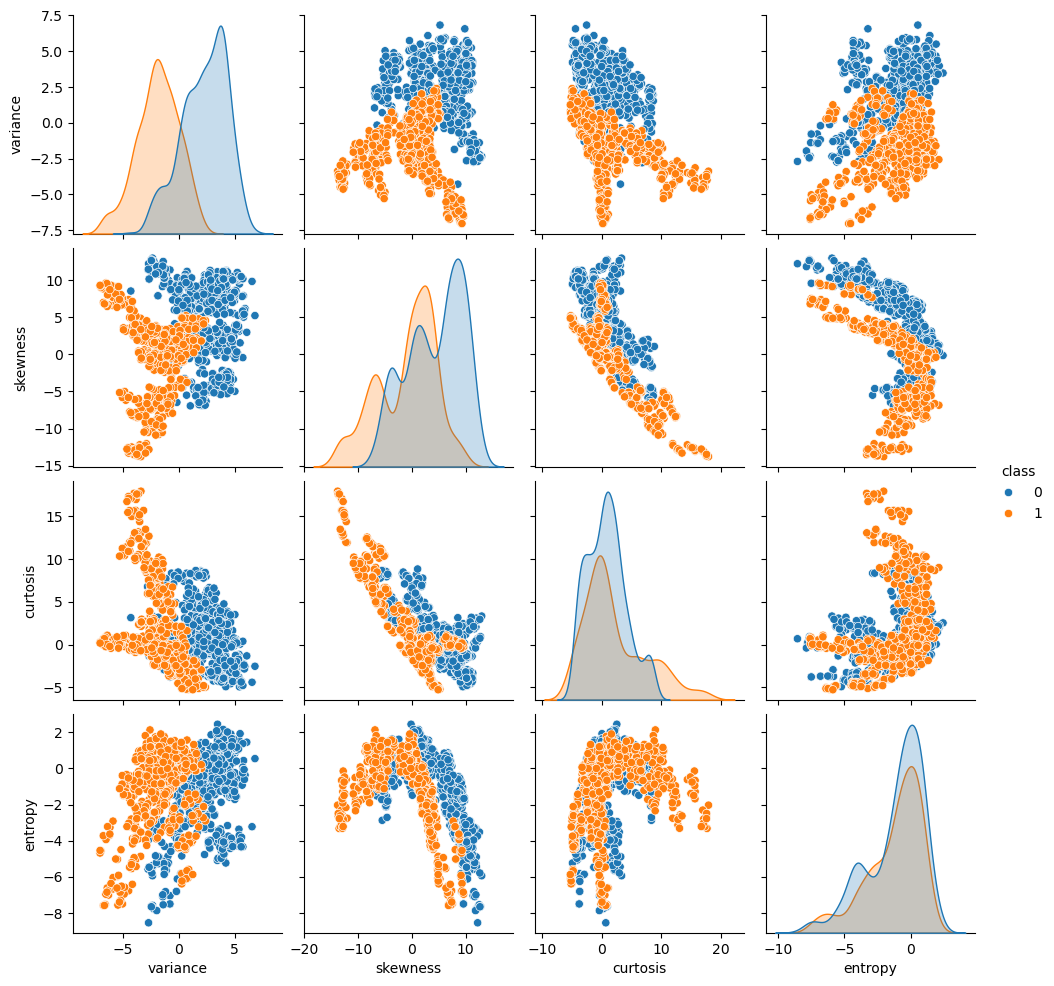

In [23]:
sns.pairplot(df, hue='class')
plt.show()

# Standardize the Variables

Time to standardize the variables.

**Import `StandardScaler` from Scikit-Learn.**

In [24]:
from sklearn.preprocessing import StandardScaler

**Create a `StandardScaler()` object called `scaler`.**

In [25]:
scaler = StandardScaler()

**Fit `scaler` to the features.**

In [26]:
scaler.fit(df.drop('class', axis=1))

StandardScaler()

**Use the `.transform()` method to transform the features to a scaled version.**

In [27]:
scaled_features = scaler.transform(df.drop('class', axis=1))
scaled_features[:5]

array([[ 1.12180565,  1.14945512, -0.97597007,  0.35456135],
       [ 1.44706568,  1.06445293, -0.89503626, -0.12876744],
       [ 1.20780971, -0.77735215,  0.12221838,  0.61807317],
       [ 1.06374236,  1.29547754, -1.25539712, -1.14402883],
       [-0.03677175, -1.0870383 ,  0.73673042,  0.09658697]])

**Convert the scaled features to a dataframe and check the head of this dataframe to make sure the scaling worked.**

In [28]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_feat.head()

,variance,skewness,curtosis,entropy
0,1.121806,1.149455,-0.975970,0.354561
1,1.447066,1.064453,-0.895036,-0.128767
2,1.207810,-0.777352,0.122218,0.618073
3,1.063742,1.295478,-1.255397,-1.144029
4,-0.036772,-1.087038,0.736730,0.096587


# Train Test Split

**Use `train_test_split` to split your data into a training set and a testing set.**

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features, df['class'], test_size=0.30, random_state=101
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (960, 4)
X_test shape: (412, 4)
y_train shape: (960,)
y_test shape: (412,)


# Using KNN

**Import `KNeighborsClassifier` from scikit-learn.**

In [30]:
from sklearn.neighbors import KNeighborsClassifier

**Create a KNN model instance with `n_neighbors=1`.**

In [31]:
knn = KNeighborsClassifier(n_neighbors=1)

**Fit this KNN model to the training data.**

In [32]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

# Predictions and Evaluations

Let's evaluate our KNN model!

**Use the `predict` method to predict values using your KNN model and `X_test`.**

In [33]:
pred = knn.predict(X_test)
pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

**Create a confusion matrix and classification report.**

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix for k=1:")
print(confusion_matrix(y_test, pred))
print()
print("Classification Report for k=1:")
print(classification_report(y_test, pred))

Confusion Matrix for k=1:
[[236   2]
 [  0 174]]

Classification Report for k=1:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       238
           1       0.99      1.00      0.99       174

    accuracy                           1.00       412
   macro avg       0.99      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



# Choosing a K Value

Let's go ahead and use the elbow method to pick a good K Value!

**Create a for loop that trains various KNN models with different k values, then keep track of the error rate for each of these models with a list.**

In [35]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

error_rate[:10]

[np.float64(0.0048543689320388345),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173),
 np.float64(0.0024271844660194173)]

**Now create the following plot using the information from your for loop.**

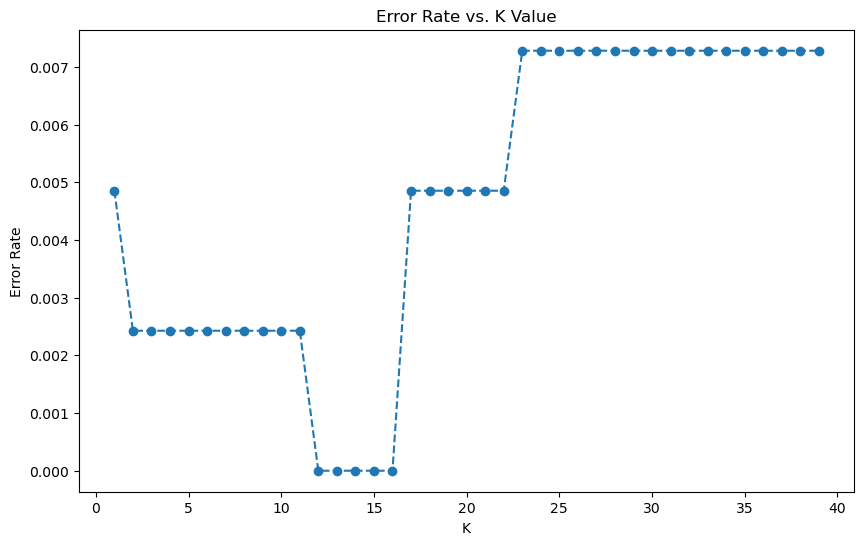

Best K based on minimum error rate: 12
Minimum error rate: 0.0


In [36]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, marker='o', linestyle='dashed')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

best_k = error_rate.index(min(error_rate)) + 1
print("Best K based on minimum error rate:", best_k)
print("Minimum error rate:", min(error_rate))

## Retrain with new K Value

**Retrain your model with the best K value and re-do the classification report and the confusion matrix.**

In [37]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print(f"Confusion Matrix for k={best_k}:")
print(confusion_matrix(y_test, pred))
print()
print(f"Classification Report for k={best_k}:")
print(classification_report(y_test, pred))

Confusion Matrix for k=12:
[[238   0]
 [  0 174]]

Classification Report for k=12:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       1.00      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



## End of notebook